In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import gensim
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



In [2]:
import pandas as pd

# Load dataset with encoding handling
df = pd.read_csv(
    r"C:\\Users\\vishnu\\programs\\Sentiment_Data\\Sentiment_Data.csv", 
    encoding='ISO-8859-1'
)

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [4]:
df.head().info

<bound method DataFrame.info of                                                Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos>

In [6]:
print(df.columns)


Index(['Tweet', 'Sentiment'], dtype='object')


In [11]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("Dataset Columns:", df.columns.tolist())
print("\nDataset Info:")
print(df.info())

# Show the first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Summary statistics for numerical columns (if any)
print("\nSummary Statistics:")
print(df.describe())


Dataset Shape: (451332, 2)
Dataset Columns: ['Tweet', 'Sentiment']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None

First 5 rows of the dataset:
                                               Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos

Summary Statistics:
         Tweet   Sentiment
count   451331      451332
unique  451279           5
top     #NAME?  Strong_Pos
freq         5      233700


In [17]:
# Filter to get only the row where 'Tweet' is null
missing_row = df[df['Tweet'].isnull()]
print(missing_row)


      Tweet Sentiment
75986   NaN   Neutral


In [18]:
df = df.dropna(subset=['Tweet'])


In [19]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
Tweet        0
Sentiment    0
dtype: int64


In [20]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data if not done already
# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')


In [21]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Lowercase the text
    text = text.lower()
    
    # Remove non-alphabetic characters (including punctuation)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stop words (optional step)
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens


In [22]:
# Apply preprocessing to the Tweet column
df['tokens'] = df['Tweet'].apply(preprocess)

# Preview the results
print(df[['Tweet', 'tokens']].head())


                                               Tweet  \
0  @_angelica_toy Happy Anniversary!!!....The Day...   
1  @McfarlaneGlenda Happy Anniversary!!!....The D...   
2  @thevivafrei @JustinTrudeau Happy Anniversary!...   
3  @NChartierET Happy Anniversary!!!....The Day t...   
4  @tabithapeters05 Happy Anniversary!!!....The D...   

                                              tokens  
0  [angelicatoy, happy, anniversarythe, day, free...  
1  [mcfarlaneglenda, happy, anniversarythe, day, ...  
2  [thevivafrei, justintrudeau, happy, anniversar...  
3  [nchartieret, happy, anniversarythe, day, free...  
4  [tabithapeters, happy, anniversarythe, day, fr...  


In [23]:
# Preview the dataset with Tweet, Sentiment, and tokens columns
print(df[['Tweet', 'Sentiment', 'tokens']].head())


                                               Tweet Sentiment  \
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos   
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos   
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos   
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos   
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos   

                                              tokens  
0  [angelicatoy, happy, anniversarythe, day, free...  
1  [mcfarlaneglenda, happy, anniversarythe, day, ...  
2  [thevivafrei, justintrudeau, happy, anniversar...  
3  [nchartieret, happy, anniversarythe, day, free...  
4  [tabithapeters, happy, anniversarythe, day, fr...  


In [24]:
# Count the number of occurrences for each sentiment type
sentiment_counts = df['Sentiment'].value_counts()

# Display the sentiment counts
print(sentiment_counts)


Sentiment
Strong_Pos    233700
Neutral        77015
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


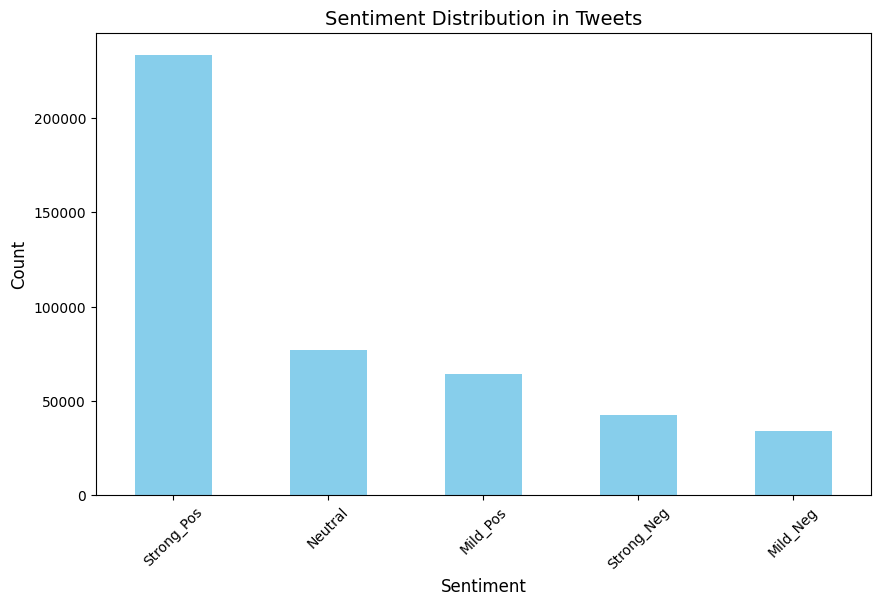

In [25]:
import matplotlib.pyplot as plt

# Get sentiment counts
sentiment_counts = df['Sentiment'].value_counts()

# Plot the bar graph
plt.figure(figsize=(10,6))
sentiment_counts.plot(kind='bar', color='skyblue')

# Set labels and title
plt.title('Sentiment Distribution in Tweets', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the plot
plt.xticks(rotation=45)
plt.show()


In [31]:
# Assuming the 'tokens' column is already a list of words
sentences = df['tokens'].apply(lambda x: x)  # No need to split, 'x' is already a list

# Now, you can train the Word2Vec model using the tokens
import gensim

# Train the Word2Vec model
word2vec_model = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

# Print some example results from the Word2Vec model
print(word2vec_model.wv.most_similar('example', topn=5))


[('judgment', 0.8402724266052246), ('imaginable', 0.8375600576400757), ('summation', 0.8346297144889832), ('indicator', 0.8340769410133362), ('imho', 0.832990288734436)]


In [33]:
import numpy as np

# Assuming get_feature_vector is a function that computes the feature vector for a list of tokens
def get_feature_vector(tokens):
    vec = np.zeros(100)  # Assuming you're using Word2Vec with 100-dimensional vectors
    count = 0
    for token in tokens:
        try:
            # Replace with the appropriate method to get word vectors, e.g., word2vec_model.wv[token]
            vec += word2vec_model.wv[token]  # Add the vector for each token
            count += 1
        except KeyError:
            continue  # If the word is not in the vocabulary, ignore it
    
    if count > 0:
        vec /= count  # Average the vectors (if there were valid words)
    
    return vec

# Apply the function to the tokens column to create feature vectors
X = np.array([get_feature_vector(tokens) for tokens in df['tokens']])

# Now X contains the feature vectors for each row in the dataset


In [34]:
# Label encoding for sentiment classes
le = LabelEncoder()
y = le.fit_transform(df['Sentiment'])  # Convert 'Sentiment' column into numeric labels


In [39]:
from sklearn.model_selection import train_test_split

# First, split the dataset into training and test sets (80% training, 20% test)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, reduce the training set size to 10,000 points
X_train_reduced, _, y_train_reduced, _ = train_test_split(X_train_full, y_train_full, train_size=10000, random_state=42)

# Reduce the test set size to 5,000 points
X_test_reduced, _, y_test_reduced, _ = train_test_split(X_test_full, y_test_full, train_size=5000, random_state=42)

# Check the new shapes of train and test data
print(X_train_reduced.shape)  # This will show (10000, 100)
print(X_test_reduced.shape)   # This will show (5000, 100)


(10000, 100)
(5000, 100)


In [40]:
print(X_train.shape)  # Correct usage: shape is an attribute, not a method
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(361064, 100)
(90267, 100)
(361064,)
(90267,)


In [42]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score

# Define the SVM model with class_weight='balanced'
svm_model = make_pipeline(
    StandardScaler(), 
    SVC(kernel='linear', class_weight='balanced', random_state=42)
)

# Train the model on the reduced training data (10,000 samples)
svm_model.fit(X_train_reduced, y_train_reduced)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(class_weight='balanced', kernel='linear',
                     random_state=42))])

In [59]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define the SVM model with class_weight='balanced'
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', class_weight='balanced', random_state=42)
)

# Perform cross-validation with 5 folds
cv_results = cross_validate(
    svm_model, X_train_reduced, y_train_reduced, 
    cv=5, scoring='accuracy', return_train_score=True
)

# Print out cross-validation results
print(f"Training scores: {cv_results['train_score']}")
print(f"Validation scores: {cv_results['test_score']}")
print(f"Average training score: {np.mean(cv_results['train_score'])}")
print(f"Average validation score: {np.mean(cv_results['test_score'])}")


Training scores: [0.488625 0.49875  0.501125 0.502625 0.5025  ]
Validation scores: [0.486  0.4645 0.4505 0.4725 0.4645]
Average training score: 0.49872500000000003
Average validation score: 0.4676


In [61]:
# Fit the model before making predictions
svm_model.fit(X_train_reduced, y_train_reduced)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(class_weight='balanced', kernel='linear',
                     random_state=42))])

In [62]:
y_pred_reduced = svm_model.predict(X_test_reduced)


In [63]:
print(y_pred_reduced)


[3 4 3 ... 0 0 4]


In [64]:
accuracy_reduced = accuracy_score(y_test_reduced, y_pred_reduced)


In [65]:
print(accuracy_reduced)

0.4722


In [66]:
# F1 Score (Positive), using 'micro', 'macro', or 'weighted' average
f1_pos_reduced = f1_score(y_test_reduced, y_pred_reduced, average='macro')  # Use 'micro', 'macro', or 'weighted'

# F1 Score (Negative), using 'micro', 'macro', or 'weighted' average
f1_neg_reduced = f1_score(y_test_reduced, y_pred_reduced, average='macro')  # Use 'micro', 'macro', or 'weighted'

# Alternatively, you can also calculate the F1 scores for all classes (positive, negative, neutral):
f1_all_classes_reduced = f1_score(y_test_reduced, y_pred_reduced, average=None)  # This gives F1 score for each class

# Print the F1 scores for each class
print(f"F1 Score (Positive) (Reduced Data): {f1_pos_reduced}")
print(f"F1 Score (Negative) (Reduced Data): {f1_neg_reduced}")
print(f"F1 Scores for all classes (Reduced Data): {f1_all_classes_reduced}")


F1 Score (Positive) (Reduced Data): 0.3875969312703759
F1 Score (Negative) (Reduced Data): 0.3875969312703759
F1 Scores for all classes (Reduced Data): [0.20401338 0.24383744 0.42255435 0.41369048 0.65388901]


In [68]:
conf_matrix_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)



In [69]:
print(conf_matrix_reduced)


[[ 122   56   45  115   42]
 [ 145  183   64  120  175]
 [ 147  104  311  136  138]
 [  89   35   30  278   37]
 [ 313  436  186  226 1467]]


In [72]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Check the unique classes in the target variable
print("Classes in y_test_reduced:", set(y_test_reduced))

# Convert the set of classes to a sorted list to avoid the axis error
classes = sorted(set(y_test_reduced))

# Binarize the labels for multiclass classification
# Ensure that the correct classes are used
y_test_binarized = label_binarize(y_test_reduced, classes=classes)  # Use the sorted classes list

# Check the shape of the binarized labels
print(f"Shape of y_test_binarized: {y_test_binarized.shape}")

# Calculate the decision function and AUC score for each class
y_score = svm_model.decision_function(X_test_reduced)

# Calculate the AUC score using one-vs-rest (OvR)
auc_score_reduced = roc_auc_score(y_test_binarized, y_score, average='macro', multi_class='ovr')

# Print the evaluation results
print(f"Accuracy (Reduced Data): {accuracy_reduced}")
print(f"F1 Score (Positive) (Reduced Data): {f1_pos_reduced}")
print(f"F1 Score (Negative) (Reduced Data): {f1_neg_reduced}")
print(f"AUC (Reduced Data): {auc_score_reduced}")
print(f"Confusion Matrix (Reduced Data):\n{conf_matrix_reduced}")


Classes in y_test_reduced: {0, 1, 2, 3, 4}
Shape of y_test_binarized: (5000, 5)
Accuracy (Reduced Data): 0.4722
F1 Score (Positive) (Reduced Data): 0.3875969312703759
F1 Score (Negative) (Reduced Data): 0.3875969312703759
AUC (Reduced Data): 0.7066661149906596
Confusion Matrix (Reduced Data):
[[ 122   56   45  115   42]
 [ 145  183   64  120  175]
 [ 147  104  311  136  138]
 [  89   35   30  278   37]
 [ 313  436  186  226 1467]]


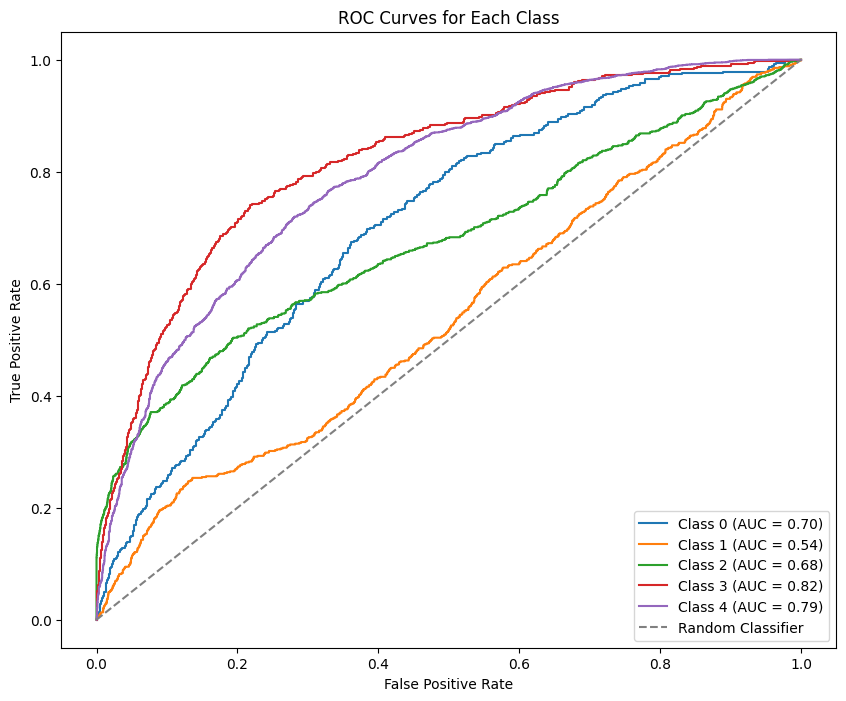

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Binarize the labels for multiclass classification
# Convert the set of classes to a sorted list
classes = sorted(set(y_test_reduced))

# Binarize the labels for multi-class classification
y_test_binarized = label_binarize(y_test_reduced, classes=classes)

# Get the decision function values (scores for each class)
y_score = svm_model.decision_function(X_test_reduced)

# Initialize a plot for the ROC curves
plt.figure(figsize=(10, 8))

# Calculate ROC curve and AUC for each class
for i, class_label in enumerate(classes):
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    
    # Compute AUC score
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc='lower right')

# Show the plot
plt.show()


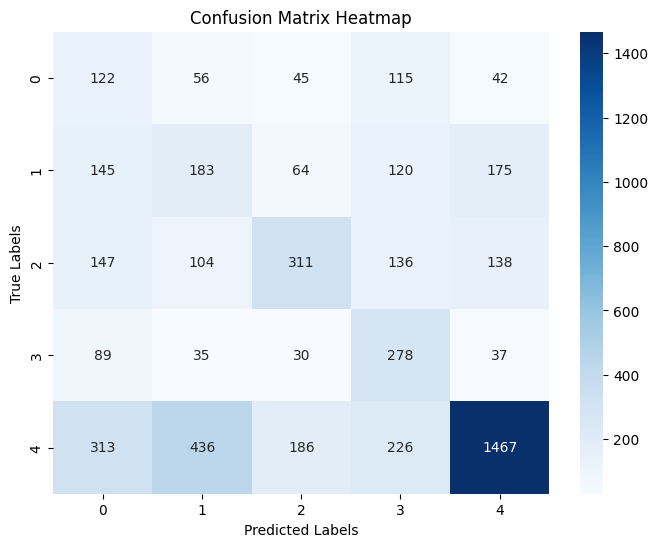

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reduced, annot=True, fmt="d", cmap="Blues", xticklabels=range(len(set(y_test_reduced))), yticklabels=range(len(set(y_test_reduced))))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Heatmap")
plt.show()


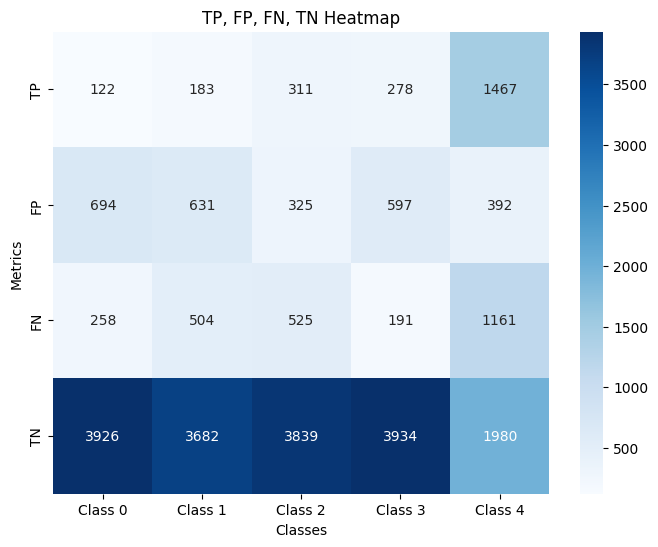

In [75]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_reduced, y_pred_reduced)

# Extract TP, FP, FN, TN
TP = np.diag(conf_matrix)  # True Positives (Diagonal elements)
FP = np.sum(conf_matrix, axis=0) - TP  # False Positives (Column-wise sum - TP)
FN = np.sum(conf_matrix, axis=1) - TP  # False Negatives (Row-wise sum - TP)
TN = np.sum(conf_matrix) - (TP + FP + FN)  # True Negatives (Total - TP - FP - FN)

# Create a DataFrame for visualization
metrics_matrix = np.array([TP, FP, FN, TN])
labels = ['TP', 'FP', 'FN', 'TN']
metrics_df = pd.DataFrame(metrics_matrix, index=labels, columns=[f'Class {i}' for i in range(conf_matrix.shape[0])])

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(metrics_df, annot=True, cmap="Blues", fmt='d')
plt.title("TP, FP, FN, TN Heatmap")
plt.xlabel("Classes")
plt.ylabel("Metrics")
plt.show()
